# **load and clean the raw data**

In [1]:
#Setup and Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
#Load Dataset
df = pd.read_csv('/content/social_media_dopamine_productivity.csv')
df.head()

,participant_id,data_source,synthetic_flag,age,age_group,gender,race_ethnicity,nationality,country_of_residence,education_level,...,mood_dependency_on_sm,withdrawal_attempt_count,longest_detox_days,detox_relapse_reason,severity_stage,productivity_decline_score,dopamine_dysregulation_index,digital_wellbeing_score,sm_addiction_risk_score,notes
0,P0001,synthetic_ai,1,16,13-17,Female,South Asian,Indian,India,High school,...,Yes,9,2,3,Boredom,Critical,8.8,9.2,2.1,9.5
1,P0002,synthetic_ai,1,17,13-17,Male,East Asian,Chinese,China,High school,...,Yes,10,1,1,Curiosity,Critical,9.5,9.8,1.5,9.8
2,P0003,synthetic_ai,1,15,13-17,Female,Black/African,Nigerian,Nigeria,High school,...,Yes,8,2,5,Boredom,Severe,8.0,8.5,2.8,9.0
3,P0004,synthetic_ai,1,19,18-22,Male,White/Caucasian,American,USA,High school,...,Yes,9,3,7,Boredom,Severe,7.8,8.2,2.9,8.8
4,P0005,synthetic_ai,1,18,18-22,Female,Hispanic/Latino,Mexican,Mexico,High school,...,Yes,9,2,4,FOMO,Critical,9.0,9.3,2.0,9.6


In [3]:
#Check DataFrame Shape
df.shape

(300, 66)

In [4]:
#Check Data Types
df.dtypes

,0
participant_id,object
data_source,object
synthetic_flag,int64
age,int64
age_group,object
...,...
productivity_decline_score,object
dopamine_dysregulation_index,float64
digital_wellbeing_score,float64
sm_addiction_risk_score,float64


In [5]:
#Descriptive Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
synthetic_flag,300.0,1.000000,0.000000,1.0,1.000,1.0,1.00,1.0
age,300.0,36.310000,15.175029,15.0,24.000,33.5,46.25,75.0
avg_daily_sm_hours,300.0,4.030000,2.034181,0.5,2.500,3.5,5.50,9.0
years_on_social_media,300.0,7.503333,2.690872,3.0,5.000,8.0,10.00,14.0
avg_daily_screen_time_hours,300.0,7.830000,2.271556,3.0,6.375,7.5,9.50,13.0
avg_sleep_hours,300.0,7.325000,1.033005,4.5,6.875,7.5,8.00,9.0
avg_work_study_hours_per_day,300.0,7.100000,2.673417,0.0,6.000,8.0,9.00,9.5
dopamine_rush_feel_score,300.0,4.920000,2.490168,1.0,3.000,4.0,7.00,10.0
reward_seeking_behavior,300.0,2.556667,1.308624,1.0,1.000,2.0,3.00,5.0
fomo_score,300.0,4.590000,2.142553,1.0,3.000,4.0,6.00,10.0


In [6]:
#Check for Missing Values
df.isnull().sum()

,0
participant_id,0
data_source,0
synthetic_flag,0
age,0
age_group,0
...,...
productivity_decline_score,0
dopamine_dysregulation_index,0
digital_wellbeing_score,0
sm_addiction_risk_score,0


In [7]:
#Check for Duplicate Rows
df.duplicated().sum()

np.int64(0)

**Drop Irrelevant Columns**

This cell removes columns identified as irrelevant for the analysis 'data_source' is one value column, 'synthetic_flag'is one value column, 'notes', 'work_quality_self_rating'and 'severity_stage' are not understood

In [8]:
#Drop Irrelevant Columns
dropped_cols = ['data_source', 'synthetic_flag', 'notes', 'work_quality_self_rating','severity_stage']
df = df.drop(columns=dropped_cols)

### **Define clean Tables**



In [9]:
#fact table
fact_cols = [
    'participant_id', 'avg_daily_sm_hours', 'avg_daily_screen_time_hours',
    'avg_work_study_hours_per_day', 'years_on_social_media', 'attention_span_minutes',
    'deep_work_duration_minutes', 'reading_duration_minutes_per_day', 'tasks_completed_per_day',
    'avg_sleep_hours', 'withdrawal_attempt_count', 'longest_detox_days',
    'productivity_self_rating', 'dopamine_rush_feel_score', 'fomo_score',
    'comparison_to_others_score', 'validation_seeking_score', 'decision_fatigue_score',
    'anxiety_when_phone_unavailable', 'restlessness_score', 'dopamine_dysregulation_index',
    'digital_wellbeing_score', 'sm_addiction_risk_score'
]

In [10]:
#Define Dimension Participant Table Columns
dim_participant_cols = [
    'participant_id', 'age', 'age_group', 'gender', 'race_ethnicity',
    'nationality', 'country_of_residence', 'education_level',
    'employment_status', 'occupation_category', 'relationship_status'
]

In [11]:
#Define Dimension Social Media Habits Table Columns
dim_habits_cols = [
    'participant_id', 'primary_platform', 'secondary_platform', 'content_type_consumed',
    'daily_check_frequency', 'first_check_of_day', 'late_night_scrolling',
    'sm_during_work_study', 'sm_during_meals', 'notifications_always_on',
    'scroll_without_purpose', 'doomscrolling_frequency'
]

In [12]:
#Define Dimension Productivity & Cognition Table Columns
dim_productivity_cols = [
    'participant_id', 'task_switching_frequency', 'difficulty_starting_tasks',
    'difficulty_maintaining_focus', 'mind_wandering_during_work',
    'creative_output_frequency', 'memory_recall_difficulty',
    'learning_retention_difficulty', 'productivity_decline_score'
]

In [13]:
#Define Dimension Mental Detox Table Columns
dim_mental_cols = [
    'participant_id', 'sleep_quality', 'exercise_frequency', 'mental_fog_frequency',
    'irritability_when_offline', 'mood_dependency_on_sm', 'reward_seeking_behavior',
    'boredom_to_phone_reflex', 'inability_to_delay_gratification', 'detox_relapse_reason'
]

In [14]:
#Create Fact and Dimension DataFrames
fact_user_metrics = df[fact_cols]
participant = df[dim_participant_cols]
social_media_habits = df[dim_habits_cols]
productivity_cognition = df[dim_productivity_cols]
mental_detox = df[dim_mental_cols]

In [15]:
#Export DataFrames to CSV
fact_user_metrics.to_csv('Fact_User_Metrics.csv', index=False)
participant.to_csv('Participant.csv', index=False)
social_media_habits.to_csv('SocialMedia_Habits.csv', index=False)
productivity_cognition.to_csv('Productivity_Cognition.csv', index=False)
mental_detox.to_csv('Mental_Detox.csv', index=False)

# **Fact User Metrics — Data Preprocessing**

In [16]:
#view the data
fact_user_metrics.head()

,participant_id,avg_daily_sm_hours,avg_daily_screen_time_hours,avg_work_study_hours_per_day,years_on_social_media,attention_span_minutes,deep_work_duration_minutes,reading_duration_minutes_per_day,tasks_completed_per_day,avg_sleep_hours,...,dopamine_rush_feel_score,fomo_score,comparison_to_others_score,validation_seeking_score,decision_fatigue_score,anxiety_when_phone_unavailable,restlessness_score,dopamine_dysregulation_index,digital_wellbeing_score,sm_addiction_risk_score
0,P0001,7.5,11.0,6.0,4,8,20,10,3,5.5,...,9,8,7,8,8,9,8,8.8,9.2,2.1
1,P0002,8.0,12.0,5.5,5,7,15,8,2,5.0,...,10,9,8,9,9,10,9,9.5,9.8,1.5
2,P0003,6.5,10.0,6.5,3,10,25,12,4,6.0,...,8,7,7,7,7,8,7,8.0,8.5,2.8
3,P0004,6.0,10.5,5.0,6,12,25,15,3,6.0,...,8,7,6,6,7,8,8,7.8,8.2,2.9
4,P0005,7.0,11.5,6.0,4,8,18,10,3,5.5,...,9,8,8,8,8,9,9,9.0,9.3,2.0


In [17]:
#Check for Missing Values
fact_user_metrics.isnull().sum()

,0
participant_id,0
avg_daily_sm_hours,0
avg_daily_screen_time_hours,0
avg_work_study_hours_per_day,0
years_on_social_media,0
attention_span_minutes,0
deep_work_duration_minutes,0
reading_duration_minutes_per_day,0
tasks_completed_per_day,0
avg_sleep_hours,0


In [18]:
#Check for Duplicate Rows
fact_user_metrics.duplicated().sum()

np.int64(0)

In [19]:
#Check for Duplications in partcipant id column
fact_user_metrics["participant_id"].duplicated().sum()

np.int64(0)

In [20]:
#Check DataFrame Shape
fact_user_metrics.shape

(300, 23)

In [21]:
#Check Data Types
fact_user_metrics.dtypes

,0
participant_id,object
avg_daily_sm_hours,float64
avg_daily_screen_time_hours,float64
avg_work_study_hours_per_day,float64
years_on_social_media,int64
attention_span_minutes,int64
deep_work_duration_minutes,int64
reading_duration_minutes_per_day,int64
tasks_completed_per_day,int64
avg_sleep_hours,float64


In [22]:
#Descriptive Statistics
fact_user_metrics.describe().T

,count,mean,std,min,25%,50%,75%,max
avg_daily_sm_hours,300.0,4.030000,2.034181,0.5,2.500,3.5,5.50,9.0
avg_daily_screen_time_hours,300.0,7.830000,2.271556,3.0,6.375,7.5,9.50,13.0
avg_work_study_hours_per_day,300.0,7.100000,2.673417,0.0,6.000,8.0,9.00,9.5
years_on_social_media,300.0,7.503333,2.690872,3.0,5.000,8.0,10.00,14.0
attention_span_minutes,300.0,27.440000,16.017541,5.0,15.000,24.0,38.00,65.0
deep_work_duration_minutes,300.0,66.203333,38.697549,10.0,35.000,60.0,95.25,150.0
reading_duration_minutes_per_day,300.0,35.480000,19.723751,5.0,20.000,35.0,55.00,72.0
tasks_completed_per_day,300.0,5.783333,2.095477,2.0,4.000,6.0,8.00,10.0
avg_sleep_hours,300.0,7.325000,1.033005,4.5,6.875,7.5,8.00,9.0
withdrawal_attempt_count,300.0,4.283333,2.925449,0.0,2.000,3.0,7.00,10.0


In [23]:
#Chech the numerical columns
numerical_cols = fact_user_metrics.select_dtypes(
    include=np.number
).columns.tolist()

if numerical_cols:
    print("Numerical Columns:")
    print(numerical_cols)
else:
    print("There are no numerical columns.")

Numerical Columns:
['avg_daily_sm_hours', 'avg_daily_screen_time_hours', 'avg_work_study_hours_per_day', 'years_on_social_media', 'attention_span_minutes', 'deep_work_duration_minutes', 'reading_duration_minutes_per_day', 'tasks_completed_per_day', 'avg_sleep_hours', 'withdrawal_attempt_count', 'longest_detox_days', 'productivity_self_rating', 'dopamine_rush_feel_score', 'fomo_score', 'comparison_to_others_score', 'validation_seeking_score', 'decision_fatigue_score', 'anxiety_when_phone_unavailable', 'restlessness_score', 'dopamine_dysregulation_index', 'digital_wellbeing_score', 'sm_addiction_risk_score']


**Check the outliers**

The results showed that most variables have 0 outliers However, avg_work_study_hours_per_day has 30 potential outliers

In [24]:
numeric_columns = fact_user_metrics.select_dtypes(
    include=np.number
).columns

for col in numeric_columns:
    Q1 = fact_user_metrics[col].quantile(0.25)
    Q3 = fact_user_metrics[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = (
        (fact_user_metrics[col] < lower) |
        (fact_user_metrics[col] > upper)
    ).sum()

    print(f"{col}: {count} outliers")

avg_daily_sm_hours: 0 outliers
avg_daily_screen_time_hours: 0 outliers
avg_work_study_hours_per_day: 30 outliers
years_on_social_media: 0 outliers
attention_span_minutes: 0 outliers
deep_work_duration_minutes: 0 outliers
reading_duration_minutes_per_day: 0 outliers
tasks_completed_per_day: 0 outliers
avg_sleep_hours: 10 outliers
withdrawal_attempt_count: 0 outliers
longest_detox_days: 0 outliers
productivity_self_rating: 0 outliers
dopamine_rush_feel_score: 0 outliers
fomo_score: 0 outliers
comparison_to_others_score: 0 outliers
validation_seeking_score: 3 outliers
decision_fatigue_score: 3 outliers
anxiety_when_phone_unavailable: 0 outliers
restlessness_score: 0 outliers
dopamine_dysregulation_index: 0 outliers
digital_wellbeing_score: 0 outliers
sm_addiction_risk_score: 0 outliers


# **Participant — Data Preprocessing**

In [25]:
#view the data
participant.head()

,participant_id,age,age_group,gender,race_ethnicity,nationality,country_of_residence,education_level,employment_status,occupation_category,relationship_status
0,P0001,16,13-17,Female,South Asian,Indian,India,High school,Student,Education,Single
1,P0002,17,13-17,Male,East Asian,Chinese,China,High school,Student,Education,Single
2,P0003,15,13-17,Female,Black/African,Nigerian,Nigeria,High school,Student,Education,Single
3,P0004,19,18-22,Male,White/Caucasian,American,USA,High school,Student,Education,Single
4,P0005,18,18-22,Female,Hispanic/Latino,Mexican,Mexico,High school,Student,Education,Single


In [26]:
#Check for Missing Values
participant.isnull().sum()

,0
participant_id,0
age,0
age_group,0
gender,0
race_ethnicity,0
nationality,0
country_of_residence,0
education_level,0
employment_status,0
occupation_category,0


In [27]:
#Check for Duplicate Rows
participant.duplicated().sum()

np.int64(0)

In [28]:
#Check for Duplications in partcipant id column
participant["participant_id"].duplicated().sum()

np.int64(0)

In [29]:
#Check DataFrame Shape
participant.shape

(300, 11)

In [30]:
#Check Data Types
participant.dtypes

,0
participant_id,object
age,int64
age_group,object
gender,object
race_ethnicity,object
nationality,object
country_of_residence,object
education_level,object
employment_status,object
occupation_category,object


In [31]:
#Descriptive Statistics
participant.describe().T

,count,mean,std,min,25%,50%,75%,max
age,300.0,36.31,15.175029,15.0,24.0,33.5,46.25,75.0


In [32]:
object_cols = participant.select_dtypes(include="object").columns

for col in object_cols:

    if col != "participant_id":

        print(f"\n{'='*40}")
        print(f"{col}:")
        print("Number of unique values:", participant[col].nunique())


age_group:
Number of unique values: 7

gender:
Number of unique values: 3

race_ethnicity:
Number of unique values: 7

nationality:
Number of unique values: 39

country_of_residence:
Number of unique values: 39

education_level:
Number of unique values: 3

employment_status:
Number of unique values: 7

occupation_category:
Number of unique values: 14

relationship_status:
Number of unique values: 4


In [33]:
#Chech the numerical columns
numerical_cols = participant.select_dtypes(
    include=np.number
).columns.tolist()

if numerical_cols:
    print("Numerical Columns:")
    print(numerical_cols)
else:
    print("There are no numerical columns.")

Numerical Columns:
['age']


**Check the Outliers**

There is no outliers


In [34]:
Q1 = participant["age"].quantile(0.25)
Q3 = participant["age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

age_outliers = participant[
    (participant["age"] < lower) |
    (participant["age"] > upper)
]

print("Number of age outliers:", len(age_outliers))

Number of age outliers: 0


# **social media habits — Data Preprocessing**

In [35]:
#view the data
social_media_habits.head()

,participant_id,primary_platform,secondary_platform,content_type_consumed,daily_check_frequency,first_check_of_day,late_night_scrolling,sm_during_work_study,sm_during_meals,notifications_always_on,scroll_without_purpose,doomscrolling_frequency
0,P0001,Instagram,YouTube,Short video/Reels,Constantly,Within 5 mins of waking,Daily,Always,Always,Yes,Yes,Daily
1,P0002,TikTok,YouTube,Short video/Reels,Constantly,Within 5 mins of waking,Daily,Always,Always,Yes,Yes,Daily
2,P0003,TikTok,Instagram,Short video/Reels,Every few hours,Within 30 mins,Daily,Often,Often,Yes,Yes,Daily
3,P0004,YouTube,Reddit,Gaming/Tech content,Every few hours,Within 30 mins,Daily,Often,Sometimes,Yes,Yes,Daily
4,P0005,Instagram,TikTok,Short video/Reels,Constantly,Within 5 mins of waking,Daily,Always,Often,Yes,Yes,Daily


In [36]:
#Check for Missing Values
social_media_habits.isnull().sum()

,0
participant_id,0
primary_platform,0
secondary_platform,3
content_type_consumed,0
daily_check_frequency,0
first_check_of_day,0
late_night_scrolling,0
sm_during_work_study,0
sm_during_meals,0
notifications_always_on,0


In [37]:
#Check for Duplicate Rows
social_media_habits.duplicated().sum()

np.int64(0)

In [38]:
#Check for Duplications in partcipant id column
social_media_habits["participant_id"].duplicated().sum()

np.int64(0)

In [39]:
#Check DataFrame Shape
social_media_habits.shape

(300, 12)

In [40]:
#Check Data Types
social_media_habits.dtypes

,0
participant_id,object
primary_platform,object
secondary_platform,object
content_type_consumed,object
daily_check_frequency,object
first_check_of_day,object
late_night_scrolling,object
sm_during_work_study,object
sm_during_meals,object
notifications_always_on,object


In [41]:
#Descriptive Statistics
social_media_habits.describe().T

,count,unique,top,freq
participant_id,300,300,P0300,1
primary_platform,300,9,Instagram,95
secondary_platform,297,16,YouTube,65
content_type_consumed,300,76,Short video/Reels,33
daily_check_frequency,300,5,2-3 times a day,114
first_check_of_day,300,4,Within 30 mins,150
late_night_scrolling,300,5,Sometimes,86
sm_during_work_study,300,5,Sometimes,100
sm_during_meals,300,5,Rarely,110
notifications_always_on,300,2,Yes,205


In [42]:
#Chech the numerical columns
numerical_cols = social_media_habits.select_dtypes(
    include=np.number
).columns.tolist()

if numerical_cols:
    print("Numerical Columns:")
    print(numerical_cols)
else:
    print("There are no numerical columns.")

There are no numerical columns.


# **productivity_cognition — Data Preprocessing**

In [43]:
#view the data
productivity_cognition.head()

,participant_id,task_switching_frequency,difficulty_starting_tasks,difficulty_maintaining_focus,mind_wandering_during_work,creative_output_frequency,memory_recall_difficulty,learning_retention_difficulty,productivity_decline_score
0,P0001,High,Yes,Yes,Yes,Low,Yes,Yes,Critical
1,P0002,High,Yes,Yes,Yes,Low,Yes,Yes,Critical
2,P0003,High,Yes,Yes,Yes,Low,Yes,Yes,Severe
3,P0004,High,Yes,Yes,Yes,Low,Yes,Yes,Severe
4,P0005,High,Yes,Yes,Yes,Low,Yes,Yes,Critical


In [44]:
#Check for Missing Values
productivity_cognition.isnull().sum()

,0
participant_id,0
task_switching_frequency,0
difficulty_starting_tasks,0
difficulty_maintaining_focus,0
mind_wandering_during_work,0
creative_output_frequency,0
memory_recall_difficulty,0
learning_retention_difficulty,0
productivity_decline_score,0


In [45]:
#Check for Duplicate Rows
productivity_cognition.duplicated().sum()

np.int64(0)

In [46]:
#Check for Duplications in partcipant id column
productivity_cognition["participant_id"].duplicated().sum()

np.int64(0)

In [47]:
#Check DataFrame Shape
productivity_cognition.shape

(300, 9)

In [48]:
#Check Data Types
productivity_cognition.dtypes

,0
participant_id,object
task_switching_frequency,object
difficulty_starting_tasks,object
difficulty_maintaining_focus,object
mind_wandering_during_work,object
creative_output_frequency,object
memory_recall_difficulty,object
learning_retention_difficulty,object
productivity_decline_score,object


In [49]:
#Descriptive Statistics
productivity_cognition.describe().T

,count,unique,top,freq
participant_id,300,300,P0300,1
task_switching_frequency,300,3,Low,160
difficulty_starting_tasks,300,4,Rarely,121
difficulty_maintaining_focus,300,4,Sometimes,106
mind_wandering_during_work,300,4,Rarely,131
creative_output_frequency,300,6,Good,116
memory_recall_difficulty,300,4,Rarely,133
learning_retention_difficulty,300,4,Rarely,133
productivity_decline_score,300,5,None/Minimal,154


In [50]:
#Check the numerical columns
numerical_cols = productivity_cognition.select_dtypes(
    include=np.number
).columns.tolist()

if numerical_cols:
    print("Numerical Columns:")
    print(numerical_cols)
else:
    print("There are no numerical columns.")

There are no numerical columns.


# **mental_detox — Data Preprocessing**

In [51]:
#view the data
mental_detox.head()

,participant_id,sleep_quality,exercise_frequency,mental_fog_frequency,irritability_when_offline,mood_dependency_on_sm,reward_seeking_behavior,boredom_to_phone_reflex,inability_to_delay_gratification,detox_relapse_reason
0,P0001,Poor,Never,Daily,Yes,Yes,5,Yes,Yes,3
1,P0002,Very poor,Never,Daily,Yes,Yes,5,Yes,Yes,1
2,P0003,Poor,1-2x/week,Daily,Yes,Yes,4,Yes,Yes,5
3,P0004,Poor,1-2x/week,Daily,Yes,Yes,4,Yes,Yes,7
4,P0005,Poor,Never,Daily,Yes,Yes,5,Yes,Yes,4


In [52]:
#Check for Missing Values
mental_detox.isnull().sum()

,0
participant_id,0
sleep_quality,0
exercise_frequency,0
mental_fog_frequency,0
irritability_when_offline,0
mood_dependency_on_sm,0
reward_seeking_behavior,0
boredom_to_phone_reflex,0
inability_to_delay_gratification,0
detox_relapse_reason,0


In [53]:
#Check for Duplicate Rows
mental_detox.duplicated().sum()

np.int64(0)

In [54]:
#Check for Duplications in partcipant id column
mental_detox["participant_id"].duplicated().sum()

np.int64(0)

In [55]:
#Check DataFrame Shape
mental_detox.shape

(300, 10)

In [56]:
#Check Data Types
mental_detox.dtypes

,0
participant_id,object
sleep_quality,object
exercise_frequency,object
mental_fog_frequency,object
irritability_when_offline,object
mood_dependency_on_sm,object
reward_seeking_behavior,int64
boredom_to_phone_reflex,object
inability_to_delay_gratification,object
detox_relapse_reason,int64


In [57]:
#Descriptive Statistics
mental_detox.describe().T

,count,mean,std,min,25%,50%,75%,max
reward_seeking_behavior,300.0,2.556667,1.308624,1.0,1.0,2.0,3.0,5.0
detox_relapse_reason,300.0,28.740000,23.587999,1.0,10.0,24.0,48.0,90.0


In [58]:
object_cols = mental_detox.select_dtypes(include="object").columns

for col in object_cols:
    if col != "participant_id":
        print(f"\n{'='*40}")
        print(f"{col}:")
        print("Number of unique values:", mental_detox[col].nunique())
        print("\nValues and their frequencies:")
        print(mental_detox[col].value_counts())


sleep_quality:
Number of unique values: 5

Values and their frequencies:
sleep_quality
Good         146
Fair          75
Poor          43
Very good     26
Very poor     10
Name: count, dtype: int64

exercise_frequency:
Number of unique values: 4

Values and their frequencies:
exercise_frequency
1-2x/week    102
3-4x/week     79
Daily         71
Never         48
Name: count, dtype: int64

mental_fog_frequency:
Number of unique values: 5

Values and their frequencies:
mental_fog_frequency
Never        85
Rarely       76
Daily        65
Often        55
Sometimes    19
Name: count, dtype: int64

irritability_when_offline:
Number of unique values: 4

Values and their frequencies:
irritability_when_offline
Rarely       108
Yes           91
Sometimes     61
Never         40
Name: count, dtype: int64

mood_dependency_on_sm:
Number of unique values: 4

Values and their frequencies:
mood_dependency_on_sm
Rarely       102
Yes           73
Sometimes     66
Never         59
Name: count, dtype: int

In [59]:
#Check the numerical columns
numerical_cols = mental_detox.select_dtypes(
    include=np.number
).columns.tolist()

if numerical_cols:
    print("Numerical Columns:")
    print(numerical_cols)
else:
    print("There are no numerical columns.")

Numerical Columns:
['reward_seeking_behavior', 'detox_relapse_reason']


**Check the outliers**

there is no outliers

In [60]:
outlier_cols = [
    col for col in numerical_cols
    if col != "participant_id"
]

if outlier_cols:
    for col in outlier_cols:
        Q1 = mental_detox[col].quantile(0.25)
        Q3 = mental_detox[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = mental_detox[
            (mental_detox[col] < lower) |
            (mental_detox[col] > upper)
        ]

        print(f"{col}: {len(outliers)} outliers")
else:
    print("There are no numerical columns for outlier detection.")

reward_seeking_behavior: 0 outliers
detox_relapse_reason: 0 outliers


# **Feature engineering**

1.Social Media Usage Level: Users were categorized into 'Low', 'Medium', and 'High' usage based on their average daily social media hours.

2.Addiction Risk Level: Users were categorized into 'Low', 'Medium', and 'High' risk based on their social media addiction risk score (1–10).

3.Sleep Level: Users were categorized into 'Low Sleep', 'Adequate Sleep', and 'High Sleep' based on their average sleep hours.

4.on-Social Screen Time: Calculated by subtracting average daily social media hours from average daily screen time hours.

5.Reward Seeking Level, was created from reward_seeking_behavior that 1-2 is Low,3 is Moderate and 4–5 is: High

In [61]:
#Social Media Usage Level
fact_user_metrics["social_media_usage_level"] = pd.cut(
    fact_user_metrics["avg_daily_sm_hours"],
    bins=[-np.inf, 3, 6, np.inf],
    labels=["Low", "Medium", "High"]
)
fact_user_metrics[
    ["avg_daily_sm_hours", "social_media_usage_level"]
].head()

/tmp/ipykernel_64715/2524905421.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_user_metrics["social_media_usage_level"] = pd.cut(


,avg_daily_sm_hours,social_media_usage_level
0,7.5,High
1,8.0,High
2,6.5,High
3,6.0,Medium
4,7.0,High


In [62]:
#Addiction Risk Level
fact_user_metrics["addiction_risk_level"] = pd.cut(
    fact_user_metrics["sm_addiction_risk_score"],
    bins=[0, 3, 7, 10],
    labels=["Low Risk", "Medium Risk", "High Risk"],
)
fact_user_metrics[
    ["sm_addiction_risk_score", "addiction_risk_level"]
].head(10)

/tmp/ipykernel_64715/1467498290.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_user_metrics["addiction_risk_level"] = pd.cut(


,sm_addiction_risk_score,addiction_risk_level
0,2.1,Low Risk
1,1.5,Low Risk
2,2.8,Low Risk
3,2.9,Low Risk
4,2.0,Low Risk
5,2.7,Low Risk
6,3.2,Medium Risk
7,4.0,Medium Risk
8,2.0,Low Risk
9,3.5,Medium Risk


In [63]:
#Sleep Level
fact_user_metrics["sleep_level"] = pd.cut(
    fact_user_metrics["avg_sleep_hours"],
    bins=[-np.inf, 6, 8, np.inf],
    labels=["Low Sleep", "Adequate Sleep", "High Sleep"]
)
fact_user_metrics[
    ["avg_sleep_hours", "sleep_level"]
].head(10)

/tmp/ipykernel_64715/2874477329.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_user_metrics["sleep_level"] = pd.cut(


,avg_sleep_hours,sleep_level
0,5.5,Low Sleep
1,5.0,Low Sleep
2,6.0,Low Sleep
3,6.0,Low Sleep
4,5.5,Low Sleep
5,6.0,Low Sleep
6,6.5,Adequate Sleep
7,6.5,Adequate Sleep
8,5.5,Low Sleep
9,6.5,Adequate Sleep


In [64]:
#Non-Social Screen Time
fact_user_metrics["non_social_screen_time_hours"] = (
    fact_user_metrics["avg_daily_screen_time_hours"]
    - fact_user_metrics["avg_daily_sm_hours"]
)

fact_user_metrics[
    fact_user_metrics["non_social_screen_time_hours"] < 0
]
fact_user_metrics[
    ["non_social_screen_time_hours"]
].head()

/tmp/ipykernel_64715/3139310821.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_user_metrics["non_social_screen_time_hours"] = (


,non_social_screen_time_hours
0,3.5
1,4.0
2,3.5
3,4.5
4,4.5


In [65]:
#reward_seeking_level
mental_detox["reward_seeking_level"] = pd.cut(
    mental_detox["reward_seeking_behavior"],
    bins=[0, 2, 3, 5],
    labels=["Low", "Moderate", "High"],
    include_lowest=True
)
mental_detox[
    ["reward_seeking_behavior", "reward_seeking_level"]
].value_counts().sort_index()

/tmp/ipykernel_64715/2885672140.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mental_detox["reward_seeking_level"] = pd.cut(


,,count
reward_seeking_behavior,reward_seeking_level,
1,Low,76
2,Low,89
3,Moderate,62
4,High,38
5,High,35


# **Visualizations**

In [66]:
#Relationship between platforms and screen time
import plotly.express as px

metrics = {
    "Screen Time": "avg_daily_sm_hours",
    "Productivity": "productivity_self_rating",
    "Addiction Risk": "sm_addiction_risk_score",
    "Attention Span": "attention_span_minutes"
}

metric = "Screen Time"

data = df.groupby("primary_platform")[metrics[metric]].mean().reset_index()

fig = px.bar(
    data.sort_values(metrics[metric]),
    x=metrics[metric],
    y="primary_platform",
    orientation="h",
    title=f"<b>Top Platforms by {metric}</b>",
    labels={metrics[metric]: metric, "primary_platform": "Platform"},
    color_discrete_sequence=["#5B8C5A"]
)

fig.update_layout(
    template="plotly_white",
    paper_bgcolor="#F5F5EE",
    plot_bgcolor="#F5F5EE",
    font_color="#333333",
    title_font_color="#111111"
)

fig.update_xaxes(gridcolor="#C3E3C5")
fig.update_yaxes(gridcolor="#C3E3C5")

fig.show()

In [67]:
#Relationship between screen time and prouctivity
settings = {
    "x": "avg_daily_screen_time_hours",
    "y": "productivity_self_rating",
    "nbinsx": 12,
    "nbinsy": 9,
    "range_x": [2, 14],
    "range_y": [2, 10],
    "color_continuous_scale": [
        "#F5F5EE",
        "#C3E3C5",
        "#71C1B3",
        "#537370",
        "#5B8C5A"
    ]
}

fig = px.density_heatmap(df, **settings)

fig.update_layout(
    title="<b>Section 2: Screen Time vs Productivity </b>",
    xaxis_title="Avg Daily Screen Time Hours",
    yaxis_title="Productivity Self Rating",
    coloraxis_colorbar_title="count",
    paper_bgcolor="#F5F5EE",
    plot_bgcolor="#F5F5EE",
    font_color="#333333"
)

fig.update_xaxes(gridcolor="#C3E3C5")
fig.update_yaxes(gridcolor="#C3E3C5")

fig.show()

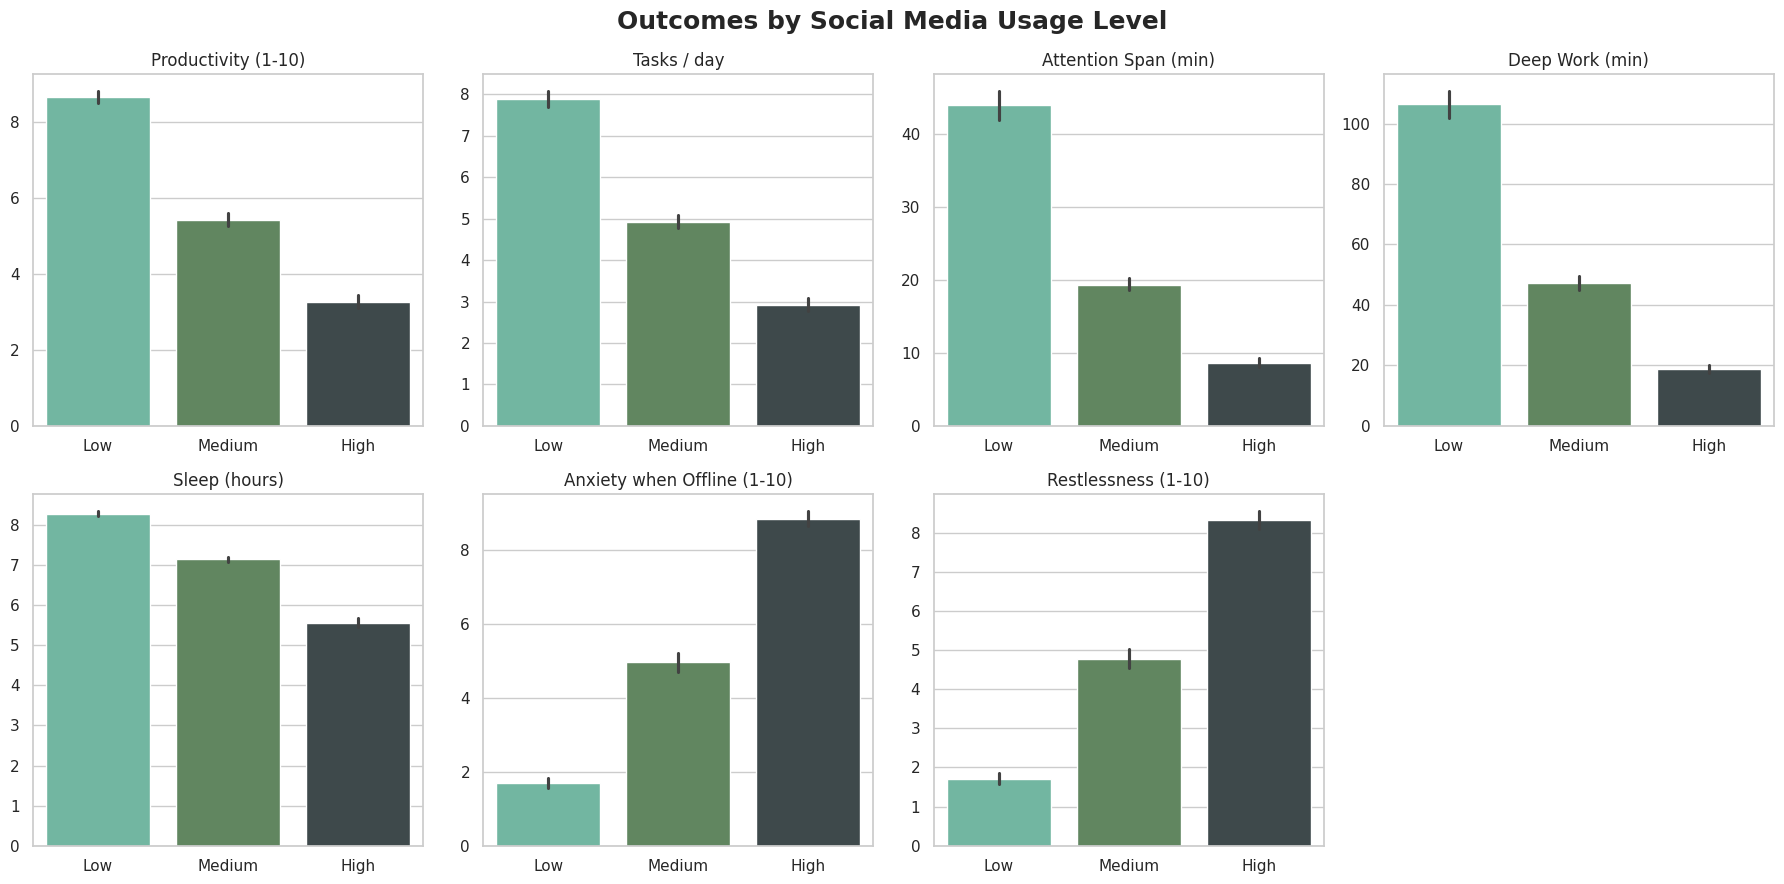

In [68]:
#social media usage level analysis
sns.set_theme(style="whitegrid")


# Feature on X-axis
x_feature = "social_media_usage_level"


# Outcomes on Y-axis
outcomes = {
    "Productivity (1-10)": "productivity_self_rating",
    "Tasks / day": "tasks_completed_per_day",
    "Attention Span (min)": "attention_span_minutes",
    "Deep Work (min)": "deep_work_duration_minutes",
    "Sleep (hours)": "avg_sleep_hours",
    "Anxiety when Offline (1-10)": "anxiety_when_phone_unavailable",
    "Restlessness (1-10)": "restlessness_score"
}

# Define a custom color palette for the usage levels
# The order of colors corresponds to the order of labels in pd.cut: Low, Medium, High
custom_palette = {
    "Low": "#66c2a5",
    "Medium": "#5B8C5A",
    "High": "#3C4A4D"
}


# Create subplots
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

fig.suptitle(
    "Outcomes by Social Media Usage Level",
    fontsize=18,
    fontweight="bold"
)


# Loop through the dictionary
for ax, (title, y_feature) in zip(axes.flat, outcomes.items()):

    sns.barplot(
        data=fact_user_metrics,
        x=x_feature,
        y=y_feature,
        estimator="mean",
        ax=ax,
        palette=custom_palette,
        hue=x_feature, # Assign x_feature to hue
        legend=False   # Suppress the redundant legend
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")


# Hide empty subplot
for ax in axes.flat[len(outcomes):]:
    ax.axis("off")


plt.tight_layout()
plt.show()

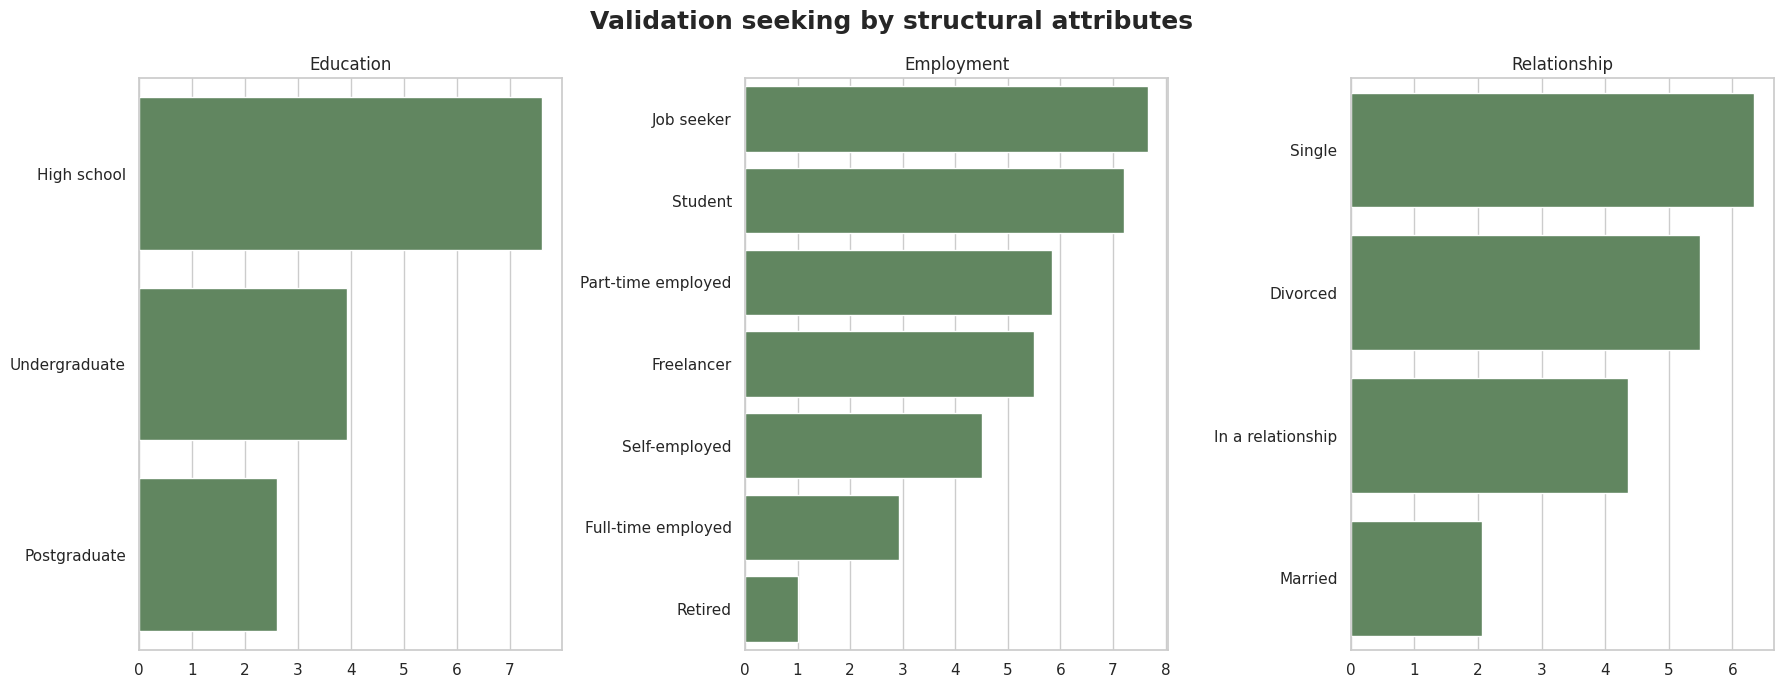

In [69]:
#validation seeking analysis
sns.set_theme(style="whitegrid")

groups = {
    "Education": (
        "education_level",
        ["High school", "Undergraduate", "Postgraduate"]
    ),
    "Employment": (
        "employment_status",
        ["Job seeker", "Student", "Part-time employed",
         "Freelancer", "Self-employed", "Full-time employed", "Retired"]
    ),
    "Relationship": (
        "relationship_status",
        ["Single", "Divorced", "In a relationship", "Married"]
    )
}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (title, (column, order)) in zip(axes, groups.items()):

    sns.barplot(
        data=df,
        x="validation_seeking_score",
        y=column,
        order=order,
        estimator="mean",
        errorbar=None,
        color="#5B8C5A",
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle(
    "Validation seeking by structural attributes",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# **Label Encoding**

In [73]:
from sklearn.preprocessing import OneHotEncoder

tables = [
    fact_user_metrics,
    participant,
    social_media_habits,
    productivity_cognition,
    mental_detox
]

for table in tables:
    cat_cols = table.select_dtypes(include="object").columns

    if len(cat_cols) > 0:
        encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        encoded = encoder.fit_transform(table[cat_cols])

        encoded_df = pd.DataFrame(
            encoded,
            columns=encoder.get_feature_names_out(cat_cols),
            index=table.index
        )

        table.drop(columns=cat_cols, inplace=True)
        table[encoded_df.columns] = encoded_df